<a href="https://colab.research.google.com/github/DzihniSafwaA1201/Image-Classification-CNN/blob/main/Tugas_Minggu_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Dataset dan Library


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [48]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dropout

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# New Section

In [ ]:
Conv2D(32, (3,3), activation='relu')

<Conv2D name=conv2d, built=False>

In [ ]:
MaxPooling2D(pool_size=(2,2))

<MaxPooling2D name=max_pooling2d, built=True>

In [ ]:
Dense(128, activation='relu')

<Dense name=dense, built=False>

In [3]:
#Jumlah Kelas
dataset_path = '/content/drive/MyDrive/Semester 6/Tugas Minggu 9 Dataset/Bean_Dataset'
classes = os.listdir(dataset_path)
print("Kelas Dataset:")
print(classes)

Kelas Dataset:
['healthy', 'bean_rust', 'angular_leaf_spot']


In [4]:
#Distribusi Data Per Kelas
for category in classes:
    folder = os.path.join(dataset_path, category)
    total = len(os.listdir(folder))
    print(f"{category} : {total} gambar")

healthy : 330 gambar
bean_rust : 330 gambar
angular_leaf_spot : 330 gambar


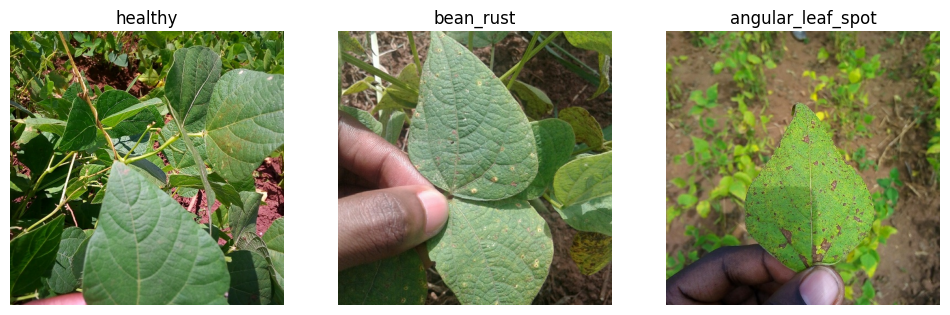

In [5]:
import cv2

plt.figure(figsize=(12,4))

for i, category in enumerate(classes):
    folder = os.path.join(dataset_path, category)
    image_name = os.listdir(folder)[0]

    image_path = os.path.join(folder, image_name)

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(category)
    plt.axis('off')

plt.show()

In [6]:
#Ukuran dan Format Gambar
for category in classes:
    folder = os.path.join(dataset_path, category)

    image_name = os.listdir(folder)[0]
    image_path = os.path.join(folder, image_name)

    img = cv2.imread(image_path)

    print(f"{category} shape: {img.shape}")

healthy shape: (500, 500, 3)
bean_rust shape: (500, 500, 3)
angular_leaf_spot shape: (500, 500, 3)


In [7]:
#Resize Gambar
img_size = (128, 128)
batch_size = 32

In [53]:
#Normalisasi Pixel
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

In [35]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

Found 792 images belonging to 3 classes.


In [36]:
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 198 images belonging to 3 classes.


In [37]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 990 images belonging to 3 classes.


# New Section

In [50]:
model = Sequential()

# Convolution Layer 1
model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(128,128,3)))
model.add(MaxPooling2D((2,2)))

# Convolution Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# Con Layer 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

#DropOut Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(3, activation='softmax'))

In [51]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [52]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

# New Section

In [54]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.3952 - loss: 1.0828 - val_accuracy: 0.4646 - val_loss: 0.9809
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.5467 - loss: 0.9577 - val_accuracy: 0.6364 - val_loss: 0.8494
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.6212 - loss: 0.8409 - val_accuracy: 0.6970 - val_loss: 0.7820
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.6566 - loss: 0.7925 - val_accuracy: 0.7727 - val_loss: 0.7138
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.6667 - loss: 0.7719 - val_accuracy: 0.7475 - val_loss: 0.6707
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.7247 - loss: 0.6683 - val_accuracy: 0.6919 - val_loss: 0.7106
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.7235 - loss: 0.6519 - val_accuracy: 0.7576 - val_loss: 0.6182
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.7121 - loss: 0.6519 - val_accuracy: 0.7273 - val_loss:

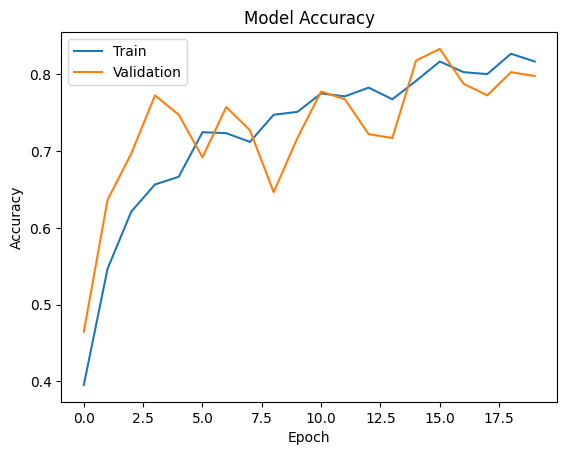

In [55]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

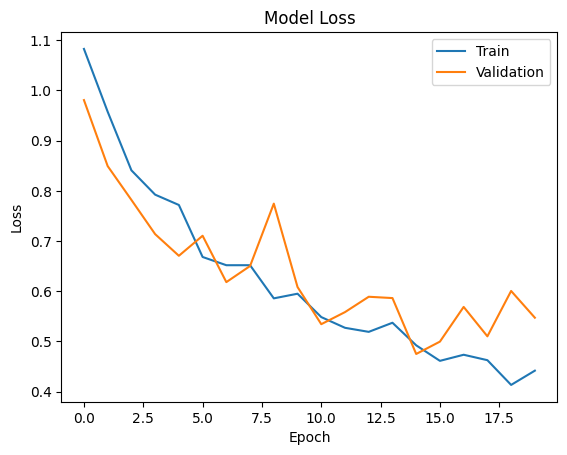

In [56]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

# New Section

In [57]:
loss, accuracy = model.evaluate(val_data)

print("Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 510ms/step - accuracy: 0.8283 - loss: 0.5415
Accuracy: 0.8282828330993652


In [58]:
predictions = model.predict(val_data)

y_pred = np.argmax(predictions, axis=1)
y_true = val_data.classes

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 505ms/step


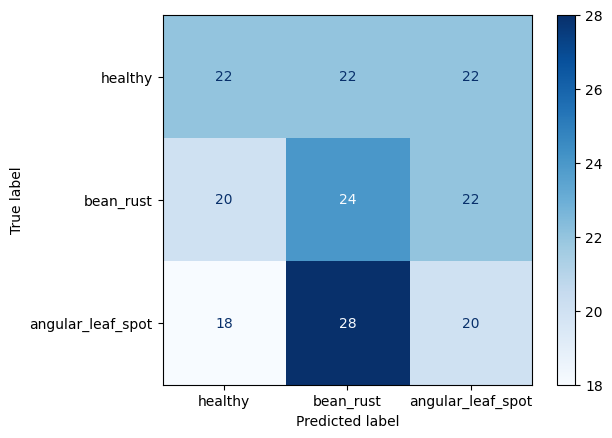

In [59]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(cmap='Blues')

plt.show()